# How to combine unity and scanimage data? 

In [1]:
from os import sys
sys.path.append('/Users/chad/Documents/GitHub/unityvr_shivy')

import numpy as np
import pandas as pd
import scipy as sp
import scipy.signal
from scipy.stats import vonmises, skew, kurtosis
import json
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import os
from os.path import sep, exists
from os import mkdir, makedirs, getcwd
import xarray as xr


from ScanImageTiffReader import ScanImageTiffReader

from fly2p.viz.viz import myAxisTheme
from fly2p.preproc.scanImageUtils import getSIbasicMetadata, getSIMetadict, loadvolume
from unityvr.analysis.align2img import generateUnityExpDf, truncateImgDataToUnityDf, addImagingTimeToUvrDat, addImagingTimeToSceneArr
from unityvr.analysis.stimAnalysis import deriveVidVals
import fly2p.preproc.imgPreproc as imp
import unityvr.analysis.waveSurferAnalysis as wsa

from unityvr.preproc import logproc as lp
from unityvr.viz import viz
from unityvr.analysis import posAnalysis, shapeAnalysis, fitting, utils
from unityvr.scripts import EB_analysis_functions as EB

from matplotlib.animation import FuncAnimation
from IPython.display import HTML

import matplotlib
from skimage.draw import polygon

matplotlib.rcParams['animation.embed_limit'] = 2**128


## Extract imaging data as an xarray

In [3]:
dirName = '/Volumes/jayaramanlab/Chad/FB6A stable-split_x_8s-RSET/Eating/cFly001/'
fileNameSI = 'fed_30min_00001.tif'

mytiffreader = ScanImageTiffReader(dirName+fileNameSI)
imgMetadat = getSIbasicMetadata(mytiffreader.metadata())
imgMetadat["CaCh"] = 0 # give channel identity
SImetadict = getSIMetadict(mytiffreader.metadata())
    
stack = loadvolume(dirName+fileNameSI, imgMetadat, selectCaChan=True)
imgStack = imp.stack2xarray(stack, imgMetadat)
print(imgMetadat)

SI.VERSION_COMMIT = '5066720ab90fa5f9bfc89c972f39266d0afd7c49'
SI.VERSION_MAJOR = 2022
SI.VERSION_MINOR = 1
SI.VERSION_UPDATE = 0
{'nCh': 1, 'fpsscan': 156.642, 'discardFBFrames': 'true', 'nDiscardFBFrames': 5, 'fpv': 16, 'nVols': 2400, 'stackZStepSize': 7.0, 'scanVolumeRate': 9.7901, 'fovCoords': {'p00': [-33.75, -33.75], 'p10': [33.75, 33.75], 'p01': [33.75, -33.75], 'p11': [-33.75, 33.75]}, 'xrange_um': 67.5, 'yrange_um': 67.5, 'CaCh': 0}


Decide if you want to use napari to visualize data

In [4]:
useNapari = False

In [5]:
if useNapari: 
    import napari 
    napari.view_image(imgStack)

## Constructing unityvr data object from log file

In [56]:
fileNameUVR = 'Log_2024-12-17_15-26-44_10_min_arena_off.json'

In [57]:
if not os.path.isdir(sep.join([dirName, fileNameUVR.replace(".json", "")])):
    uvrDat = lp.constructUnityVRexperiment(dirName, fileNameUVR, fictracSubject='Integrated', posDfKey = 'worldPosition', computePDtrace = False)
    #if using FictracSubjectIntegrated, set fictracSubject='Integrated' and posDfKey = 'worldPosition' and computePDtrace = False
    #posDfKey specifies the string that will be matched to find the chunk in the json that contains position data. For FictracSubjectIntegrated this is expected to be 'worldPosition', while for FictracSubject it is expected to be 'attemptedTranslation'.
    uvrDat.printMetadata()
    uvrDat.saveData(dirName, fileNameUVR.replace(".json", ""))
else:
    uvrDat = lp.loadUVRData(sep.join([dirName, fileNameUVR.replace(".json", ""), 'uvr']))


correcting for Unity angle convention.
No fictrac signal was recorded.
Metadata:

expid  :  testExp
experiment  :  test experiment
genotype  :  testGenotype
sex  :  NA
flyid  :  NA
trial  :  trialff
date  :  2024-12-17
time  :  15-26-44
ballRad  :  0.04500000178813934
translationalGain  :  1.0
setFrameRate  :  120
notes  :  NA
angle_convention  :  right-handed


In [7]:
#deriveVidVals(uvrDat, '', imageFile = None, sceneFile = None);
#remember uvrDat is mutable. Here we extract stimulus information if it is stored locally 

# Alignment

### Generating a dataframe from unity data with the same number of rows as imaging data
To align SI and UVR data, we need 
- `imgMetadat`: metadata from the scanimage file, 
- `imgStack['volumes [s]']`: a timeseries for each imaging volume and 
- `uvrDat`: the uvrDat class object extracted from the log file

uvrDat contains `niDf` which has the frame clock signal from SI as a time series. Unity holds these values in buffer and dumps them for each frame, such that many frame clock values exist per unity frame. We use the dips in the frame clock signal to extract when each SI frame was collected. The beginning of each volume is determined by figuring out the unity time for every nth scanimage frame where n is extracted from SI metadata (n includes flyback frames and thus accounts for them). The logged unity value at the beginning of each scanimage volume can thus be extracted and the scanimage time (volumes [s]) can then be attached to this value. 

### Sanity Check 1:
The plot below shows the unity frame clock signal as a time series for an arbitrary chunk of time in the trial. If the red dots align with the dip in the signal, then the dips are being detected correctly. 

### Sanity Check 2:
Aligns the unity time with the scanimage time to see how different the values are: if scanimgae and unity start together (as they should if unity triggers scanimage acquisition), then the plot should resemble the 45° line. Note that unity time is the _time when the unity frame was projected_ and hence each time value is repeated as many times as there are SI frame clock values for that frame.  

In [7]:
expDf = generateUnityExpDf(imgStack['volumes [s]'].values, uvrDat, imgMetadat, suppressDepugPlot = False, debugAlignmentPlots_params={'lims':[0,1000]}, findImgFrameTimes_params={'diffVal':1}).reset_index(drop=True)
# note the indices are rest because expDf is subsampled from unity data which has a much higher sample rate than the imaging data

NameError: name 'uvrDat' is not defined

`expDf` is now downsampled and contains values only from unity frames that were displayed at the beginning of each SI volume. 

**IMPORTANT**: remember to derive quantities (like speed and acceleration) before downsampling the unity values to SI rate to achieve greater accuracy (unity is >10x faster than imaging).

### Adding interpolated imaging time to the uvrDat class object

In some situations it is useful to modify the uvrDat class object to contain the _interpolated_ SI time. An example of this is if we would like to derive quantities such as speed or acceleration or if one would like to account for multiple unity frames before the volume was collected instead of the unity frame just before the volume was collected. 

**USEFUL**: uvrDat is mutable. 

In [61]:
addImagingTimeToUvrDat(imgStack['volumes [s]'].values, uvrDat, imgMetadat, generateExpDf_params={'suppressDepugPlot':True});

Number of imaging frames detected: 94104


/Users/chad/opt/anaconda3/envs/unityvr/multifunction/lib/python3.8/site-packages/scipy/interpolate/_interpolate.py:698: RuntimeWarning: divide by zero encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/Users/chad/opt/anaconda3/envs/unityvr/multifunction/lib/python3.8/site-packages/scipy/interpolate/_interpolate.py:701: RuntimeWarning: invalid value encountered in multiply
  y_new = slope*(x_new - x_lo)[:, None] + y_lo


### Truncating imaging data if necessary

Sometimes, the unity trial ends before scanimage and the imaging data needs to be truncated to achieve the same length as `expDf`. 

In [62]:
imgStack = truncateImgDataToUnityDf(imgStack, expDf)

## Sample plot for visualizing imaging and unity data

In [11]:
# stimulus is saved as png. We need to extract the stimulus intensity from the file name. 0 is black image, 1 is bright image. 
#expDf['stim'] = expDf['filename'].apply(lambda x: int(x.split('_')[-1].split('.')[0]))

(-0.9680956691503525,
 0.33798510730266573,
 -0.2511236570775509,
 1.096971159428358)

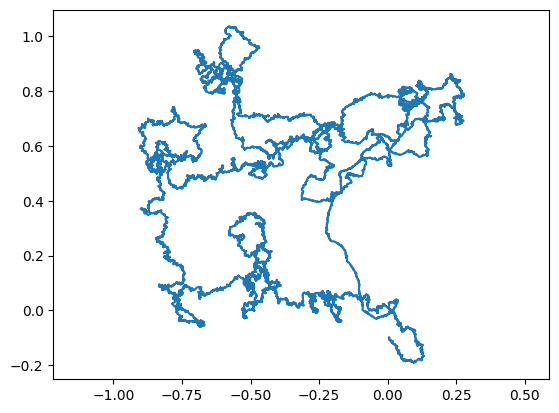

In [63]:
posDf = uvrDat.posDf
plt.plot(posDf['x'], posDf['y'])
plt.axis('equal')

/var/folders/cn/txbgqhq90h76btlrfqr0wz7w0000gn/T/ipykernel_11035/2642259612.py:19: DeprecationWarning: Please use `gaussian_filter` from the `scipy.ndimage` namespace, the `scipy.ndimage.filters` namespace is deprecated.
  from scipy.ndimage.filters import gaussian_filter


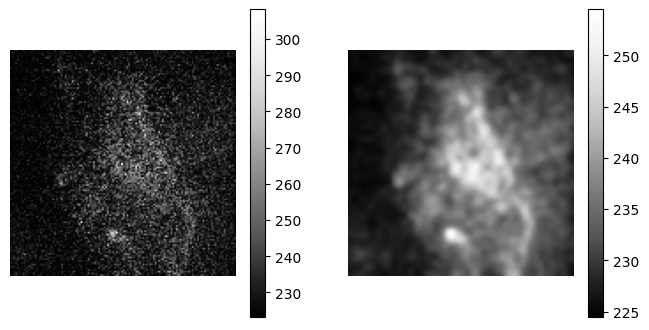

In [8]:
# Set reference image
stackMP = np.max(imgStack, axis=1) # max projection over volume

numRefImg = 20
refstart = 100
locRefImg = round(stackMP['volumes [s]'].size/2)


# Generate reference image
if not exists(sep.join([dirName, fileNameSI.replace(".tif", ""), 'refImg.npy'])):
    os.mkdir(sep.join([dirName, fileNameSI.replace(".tif", "")]))
    refImg = np.mean(stackMP[locRefImg:locRefImg+numRefImg,:,:],axis=0) #+ np.mean(stackMP[refstart:refstart+numRefImg,:,:],axis=0)
    np.save(sep.join([dirName, fileNameSI.replace(".tif", ""), 'refImg.npy']), refImg)
else:
    refImg = np.load(sep.join([dirName, fileNameSI.replace(".tif", ""), 'refImg.npy']))
    refImg = xr.DataArray(refImg)


from scipy.ndimage.filters import gaussian_filter
refImgFilt = gaussian_filter(refImg, sigma=2)

fig, axs = plt.subplots(1,2,figsize=(8,4))
im = axs[0].imshow(refImg,cmap='Greys_r', origin='lower'); axs[0].axis('off');
fig.colorbar(im, ax=axs[0], orientation='vertical')
im = axs[1].imshow(refImgFilt,cmap='Greys_r', origin='lower'); axs[1].axis('off');
fig.colorbar(im, ax=axs[1], orientation='vertical')

perform motion correction on a single plane/max projection
. . . . . . . . . . . . . . . . . . . . 

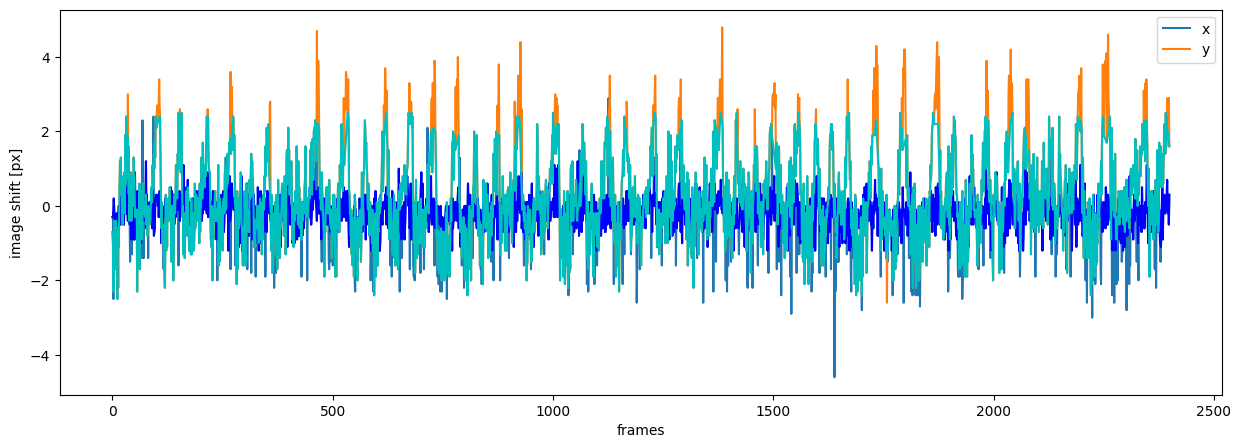

In [9]:
shift = imp.computeMotionShift(stackMP, refImg, 10, 2, doFilter=True, stdFactor=2, showShiftFig=True)
stackMPMC = imp.motionCorrection(stackMP, shift)

rawF = imp.stack2xarray(stackMPMC, imgMetadat, data4D = False)
if not exists(sep.join([dirName, fileNameSI.replace(".tif", ""), 'rawF_maxprojected_motioncorrected.nc'])):
    rawF.to_netcdf(sep.join([dirName, fileNameSI.replace(".tif", ""), 'rawF_maxprojected_motioncorrected.nc']))

In [10]:
# you can draw a mask on the foreground
import napari
viewer = napari.view_image(stackMPMC.mean(axis=0), contrast_limits=[stackMP.data.mean(axis=0).min(),np.percentile(stackMP.mean(axis=0), 99.9)])

if exists(sep.join([dirName, fileNameSI.replace(".tif", ""), 'background_3d.npy'])):
   background = np.load(sep.join([dirName, fileNameSI.replace(".tif", ""), 'background_3d.npy'])) 
   viewer.add_labels(background, name='background')

2025-01-03 13:13:31.061 python[11035:16971516] +[IMKClient subclass]: chose IMKClient_Legacy
2025-01-03 13:13:31.061 python[11035:16971516] +[IMKInputSession subclass]: chose IMKInputSession_Legacy


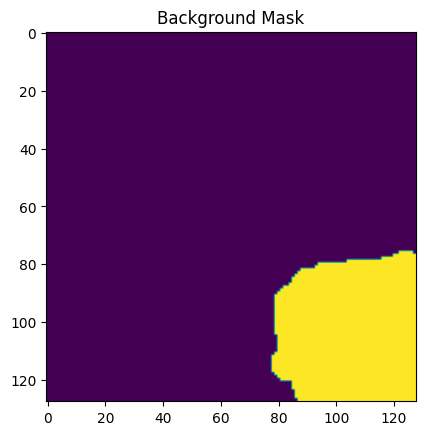

In [11]:
background = viewer.layers["background"].data

np.save(sep.join([dirName, fileNameSI.replace(".tif", ""), 'background_3d']), background)
viewer.close()

plt.imshow(background);
plt.title("Background Mask");

In [12]:
## Settings
# settings for Savitzky-Golay filter (default: 3rd order, 7 frames)
order = 3
window = 7

# Currently F_0 is estimated for each pixel on the whole time series (ok, if time series is short)
baseLinePercent = 10
offset = 0.0001

In [13]:
dffStack, stackF0 = imp.computeDFF(stackMPMC, order, window, baseLinePercent, offset, subtract=True, background_mask = background)
dffXarray = imp.stack2xarray(dffStack, imgMetadat, data4D = False)
F0Xarray = imp.refStack2xarray(stackF0, imgMetadat, data4D = False)

processing 3d stack


In [286]:
# you can draw a mask to constraint which pixels will be included in corrleation analysis
viewer = napari.view_image(refImgFilt)
if exists(sep.join([dirName, fileNameSI.replace(".tif", ""), 'mask_3d.npy'])):
    mask = np.load(sep.join([dirName,fileNameSI.replace(".tif", ""),'mask_3d.npy'])) 
    viewer.add_labels(mask, opacity=0.2)

In [287]:
import math

# Function to calculate intersection of two lines
def line_intersection(p1, p2, q1, q2):
    a1, b1 = p2[1] - p1[1], p1[0] - p2[0]
    c1 = a1 * p1[0] + b1 * p1[1]
    a2, b2 = q2[1] - q1[1], q1[0] - q2[0]
    c2 = a2 * q1[0] + b2 * q1[1]
    determinant = a1 * b2 - a2 * b1
    if determinant == 0:
        raise ValueError("Lines do not intersect")
    x = (b2 * c1 - b1 * c2) / determinant
    y = (a1 * c2 - a2 * c1) / determinant
    return np.array([x, y])

In [288]:
# Example inputs (replace with actual data from your application)
line1 = np.array(viewer.layers["line1"].data)
line2 = np.array(viewer.layers["line2"].data)

# Calculate the intersection point
intersection = line_intersection(line1[0, 0], line1[0, 1], line2[0, 0], line2[0, 1])

# Calculate angles for the arc
angle1 = math.atan2(line1[0, 1][1] - intersection[1], line1[0, 1][0] - intersection[0])
angle2 = math.atan2(line2[0, 1][1] - intersection[1], line2[0, 1][0] - intersection[0])

# Ensure angles are positive and sorted
angles = sorted([angle1, angle2])
if angles[1] - angles[0] > np.pi:
    angles = [angles[1], angles[0] + 2 * np.pi]

# Desired area of each sector
desired_area = 250000

# Calculate radius based on the desired area and total angle
total_angle = angles[1] - angles[0]
radius = math.sqrt((2 * desired_area) / total_angle)

# Generate arc points and ROIs
arc_angles = np.linspace(angles[0], angles[1], 17)  # 16 sectors
arc_rois = [
    [
        intersection,
        [
            intersection[0] + np.cos(arc_angles[i]) * radius,
            intersection[1] + np.sin(arc_angles[i]) * radius,
        ],
        [
            intersection[0] + np.cos(arc_angles[i + 1]) * radius,
            intersection[1] + np.sin(arc_angles[i + 1]) * radius,
        ],
        intersection,
    ]
    for i in range(len(arc_angles) - 1)
]


In [289]:
# Define the grid dimensions
height, width = imgStack.shape[2], imgStack.shape[3]  # Assuming the third dimension is for layers

# Initialize an empty list to store masks for each ROI
sub_rois = []

# Iterate over arc_rois
for arc_roi in arc_rois:
    # Extract row and column coordinates from vertices
    row_coords = [vertex[0].astype('int') for vertex in arc_roi]  # Y-coordinates
    col_coords = [vertex[1].astype('int') for vertex in arc_roi]  # X-coordinates

    # Get the polygon mask
    rr, cc = polygon(row_coords, col_coords, (height, width))
    mask_temp = np.zeros((height, width), dtype=bool)
    mask_temp[rr, cc] = True

    # Append the mask to the list
    sub_rois.append(mask_temp)


In [298]:
sub_rois = np.array(sub_rois).astype('int')
sub_rois = ((sub_rois + mask)-1).clip(min=0)

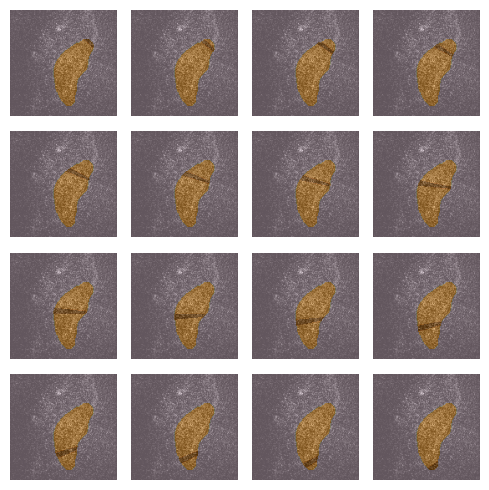

In [300]:
# Define the grid size
n_rows, n_cols = 4, 4  # 4 rows and 8 columns for 32 subplots

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5, 5))  # Adjust figsize as needed

for i in range(len(sub_rois)):  # Iterate over 32 subregions
    ax = axes[i // n_cols, i % n_cols]  # Determine the position in the grid
    ax.imshow(refImg, cmap='Greys_r', origin='upper')  # Background image
    ax.axis('off')  # Turn off the axis
    ax.imshow(mask, alpha=0.2)  # Overlay the mask
    ax.imshow(sub_rois[i, :, :], cmap='Oranges', alpha=0.35)  # Overlay the sub-region

plt.tight_layout()  # Adjust subplot spacing
plt.show()



In [302]:
ROI_masks = sub_rois.astype('int')

dffROI_all_pixel = np.zeros((np.shape(ROI_masks)[0], np.shape(dffStack)[0], np.shape(dffStack)[1], np.shape(dffStack)[2]))
for ROI in range(np.shape(ROI_masks)[0]):
    dffMasked = dffStack * ROI_masks[ROI,:,:]
    dffROI_all_pixel[ROI,:,:,:] = dffMasked

dffROI_pixel = dffROI_all_pixel.mean(axis = (2,3))

In [303]:
rawF_ROI_all = np.zeros((np.shape(ROI_masks)[0], np.shape(stackMPMC)[0], np.shape(stackMPMC)[1], np.shape(stackMPMC)[2]))
for ROI in range(np.shape(ROI_masks)[0]):
    rawF_Masked = stackMPMC * ROI_masks[ROI,:,:]
    rawF_ROI_all[ROI,:,:,:] = rawF_Masked

rawF_ROI_mean = np.nanmean((np.where(rawF_ROI_all == 0, np.nan, rawF_ROI_all)), axis = (2,3))


In [304]:
baseLinePercent = 10
offset = 0.0001
F0 = np.percentile(rawF_ROI_mean,  baseLinePercent, axis=1)
rawF_ROI_mean = rawF_ROI_mean + offset

dff_ROI = [(rawF_ROI_mean[ROI, :] - F0[ROI]) / F0[ROI] for ROI in range(len(F0))]

In [305]:
relative_weight_DFF = pd.DataFrame(np.array(dff_ROI).T)
relative_weight_DFF.columns = [ROI*(2*np.pi/relative_weight_DFF.shape[1])-np.pi for ROI in range(relative_weight_DFF.shape[1])]
angles = relative_weight_DFF.columns
weights = relative_weight_DFF.values
circular_means = EB.weighted_circular_mean_time_series(angles, weights)
 
imgDf = expDf
imgDf['PVA'] = circular_means
imgDf['angle_in_rad'] = np.deg2rad(imgDf['angle'])-np.pi

NameError: name 'expDf' is not defined

In [ ]:
rotated_heading, optimal_offset = EB.minimize_rms_difference(imgDf['PVA'], imgDf['angle_in_rad'])
imgDf['rotated_cleaned_heading']= EB.correct_circular_discontinuities(rotated_heading)
imgDf['cleaned_PVA'] = EB.correct_circular_discontinuities(imgDf['PVA'])

print('Heading offset by', np.round(optimal_offset, 3), 'rads.')

Heading offset by -1.016 rads.


NameError: name 'imgDf' is not defined

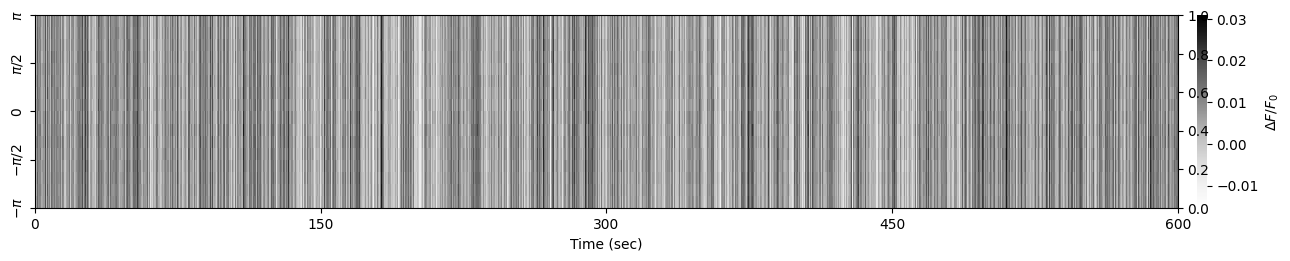

In [307]:
plt.figure(figsize=(25, 2.5))
ax = sns.heatmap(
    relative_weight_DFF.T.values,
    cmap='Greys',
    cbar_kws={'label': r'$\Delta F/F_0$',
              'fraction': 0.4,
              'pad': 0.01,
              }
)
ax.invert_yaxis()

# Set y-axis ticks and labels
yticks = [0, 4, 8, 12, 16]
ytick_labels = [r'$-\pi$', r'$-\pi/2$', r'$0$', r'$\pi/2$', r'$\pi$']
ax.set_yticks(yticks)
ax.set_yticklabels(ytick_labels)

# Set x-axis ticks and labels
xticks = [0, len(relative_weight_DFF) / 4, (len(relative_weight_DFF) / 4) * 2, (len(relative_weight_DFF) / 4) * 3, len(relative_weight_DFF)]
xtick_labels = [0, 150, 300, 450, 600]
ax.set_xticks(xticks)
ax.set_xticklabels(xtick_labels)
ax.tick_params(axis='x', rotation=0)
ax.set_xlabel('Time (sec)')

# Add a twin y-axis for additional plots
ax2 = ax.twinx()
ax2.plot(relative_weight_DFF.T.columns, imgDf['cleaned_PVA'], color='black', linewidth=0.5, alpha=0.75, label='PVA')
ax2.plot(relative_weight_DFF.T.columns, imgDf['rotated_cleaned_heading'], color='darkblue', linewidth=0.75, alpha=0.8, label='Animal Heading')

# Match y-limits and remove y-axis ticks on twin axis
ax2.set_ylim([-np.pi, np.pi])
ax2.set_yticks([])

# Add a legend for the twin axis plots
ax2.legend(loc='upper left')

plt.show()


NameError: name 'imgDf' is not defined

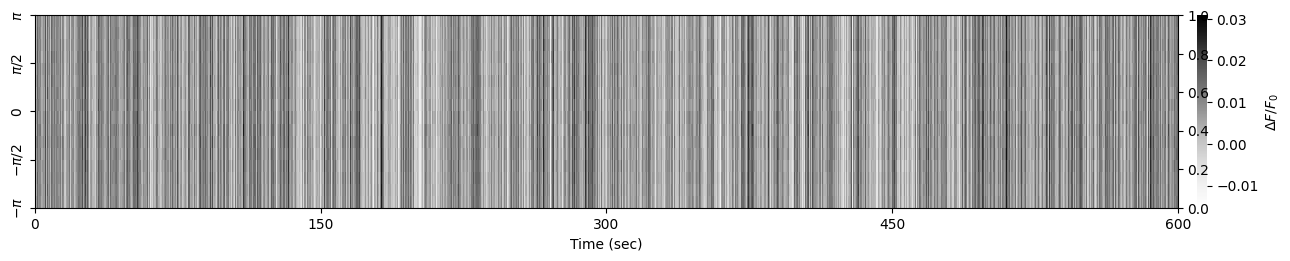

In [309]:
plt.figure(figsize=(25, 2.5))
ax = sns.heatmap(
    relative_weight_DFF.T.values,
    cmap='Greys',
    cbar_kws={'label': r'$\Delta F/F_0$',
              'fraction': 0.4,
              'pad': 0.01,
              }
)
ax.invert_yaxis()

# Set y-axis ticks and labels
yticks = [0, 4, 8, 12, 16]
ytick_labels = [r'$-\pi$', r'$-\pi/2$', r'$0$', r'$\pi/2$', r'$\pi$']
ax.set_yticks(yticks)
ax.set_yticklabels(ytick_labels)

# Set x-axis ticks and labels
xticks = [0, len(relative_weight_DFF) / 4, (len(relative_weight_DFF) / 4) * 2, (len(relative_weight_DFF) / 4) * 3, len(relative_weight_DFF)]
xtick_labels = [0, 150, 300, 450, 600]
ax.set_xticks(xticks)
ax.set_xticklabels(xtick_labels)
ax.tick_params(axis='x', rotation=0)
ax.set_xlabel('Time (sec)')

# Add a twin y-axis for additional plots
ax2 = ax.twinx()
#ax2.plot(relative_weight_DFF.T.columns, imgDf['cleaned_PVA'], color='black', linewidth=0.5, alpha=0.75, label='PVA')
ax2.plot(relative_weight_DFF.T.columns, imgDf['rotated_cleaned_heading'], color='darkblue', linewidth=0.75, alpha=0.8, label='Animal Heading')

# Match y-limits and remove y-axis ticks on twin axis
ax2.set_ylim([-np.pi, np.pi])
ax2.set_yticks([])

# Add a legend for the twin axis plots
ax2.legend(loc='upper left')

plt.show()

In [310]:
napari.view_image(dffStack)

Viewer(camera=Camera(center=(0.0, 63.5, 63.5), zoom=3.9039062499999995, angles=(0.0, 0.0, 90.0), perspective=0.0, mouse_pan=True, mouse_zoom=True), cursor=Cursor(position=(1199.0, 1.0, 0.0), scaled=True, size=1, style=<CursorStyle.STANDARD: 'standard'>), dims=Dims(ndim=3, ndisplay=2, last_used=0, range=((0.0, 2400.0, 1.0), (0.0, 128.0, 1.0), (0.0, 128.0, 1.0)), current_step=(1199, 63, 63), order=(0, 1, 2), axis_labels=('0', '1', '2')), grid=GridCanvas(stride=1, shape=(-1, -1), enabled=False), layers=[<Image layer 'dffStack' at 0x3ddc9ef70>], help='use <2> for transform', status='Ready', tooltip=Tooltip(visible=False, text=''), theme='dark', title='napari', mouse_over_canvas=False, mouse_move_callbacks=[], mouse_drag_callbacks=[], mouse_double_click_callbacks=[], mouse_wheel_callbacks=[<function dims_scroll at 0x3a6f92700>], _persisted_mouse_event={}, _mouse_drag_gen={}, _mouse_wheel_gen={}, keymap={})

In [311]:
plt.figure(figsize=(15, 2.5))

plt.plot(relative_weight_DFF.T.columns, imgDf['cleaned_PVA'], color='black', linewidth=0.5, alpha=0.75, label='PVA')
plt.plot(relative_weight_DFF.T.columns, imgDf['rotated_cleaned_heading'], color='darkblue', linewidth=0.75, alpha=0.8, label='Animal Heading')
plt.xlim([7000, 8000])

plt.show()

NameError: name 'imgDf' is not defined

<Figure size 1500x250 with 0 Axes>